## IQR

#### When to use: When data is skewed

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('https://raw.githubusercontent.com/campusx-official/100-days-of-machine-learning/refs/heads/main/day42-outlier-removal-using-zscore/placement.csv')

In [4]:
df.shape

(1000, 3)

In [5]:
df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


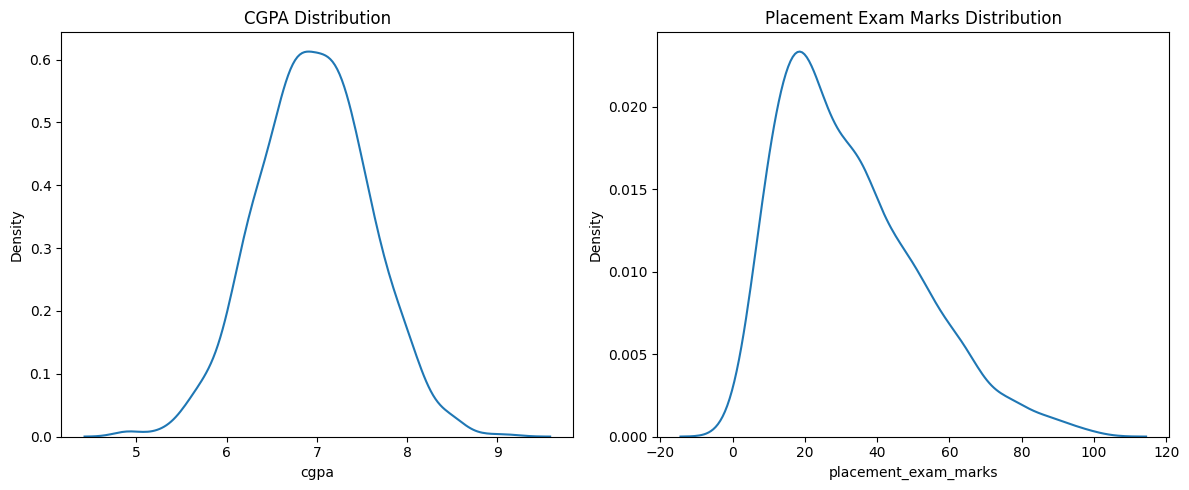

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12,5))

# left plotb
sns.kdeplot(df['cgpa'], ax=ax[0])
ax[0].set_title("CGPA Distribution")

# right plot
sns.kdeplot(df['placement_exam_marks'], ax=ax[1])
ax[1].set_title("Placement Exam Marks Distribution")

plt.tight_layout()
plt.show()

In [7]:
df['placement_exam_marks'].describe()

count    1000.000000
mean       32.225000
std        19.130822
min         0.000000
25%        17.000000
50%        28.000000
75%        44.000000
max       100.000000
Name: placement_exam_marks, dtype: float64

In [8]:
df.skew()

cgpa                   -0.014530
placement_exam_marks    0.835642
placed                  0.044077
dtype: float64

<Axes: ylabel='placement_exam_marks'>

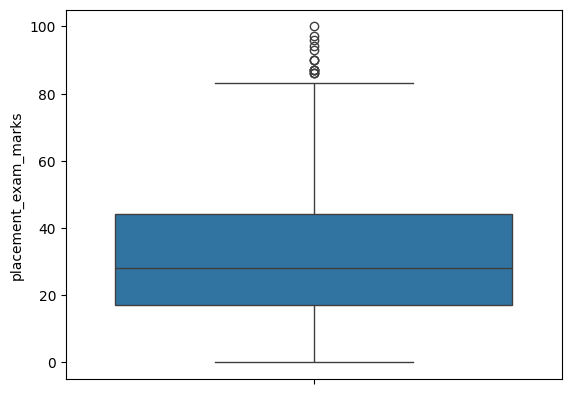

In [9]:
sns.boxplot(df['placement_exam_marks'])

In [11]:
percentile25 = df['placement_exam_marks'].quantile(0.25)
percentile75 = df['placement_exam_marks'].quantile(0.75)

In [13]:
percentile75

np.float64(44.0)

In [15]:
iqr = percentile75 - percentile25
iqr

np.float64(27.0)

In [17]:
upperlimit = percentile75 + 1.5*iqr
lowerlimit = percentile25 - 1.5*iqr

In [19]:
lowerlimit

np.float64(-23.5)

### Finding Outliers

In [24]:
df[df['placement_exam_marks'] > upperlimit]

,cgpa,placement_exam_marks,placed
9,7.75,94.0,1
40,6.60,86.0,1
61,7.51,86.0,0
134,6.33,93.0,0
162,7.80,90.0,0
283,7.09,87.0,0
290,8.38,87.0,0
311,6.97,87.0,1
324,6.64,90.0,0
630,6.56,96.0,1


In [23]:
new_df = df[df['placement_exam_marks'] < upperlimit]

In [25]:
new_df.shape

(985, 3)

#### Now we can either do capping or trimming on the data